In [26]:

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import math
from datetime import datetime
from PIL import Image
from skimage import color
from skimage import io
import cv2
import height_calculator as hc

# Load data

In [1]:
ls 20220723/pass_97_a_172436_ffc/ #ls 20220727/pass_212_164120_rfc/


frame_c301_20220723_172356_sky_bluesky.png
frame_c301_20220723_172357_sky_bluesky.png
frame_c301_20220723_172358_sky_bluesky.png
frame_c301_20220723_172359_sky_bluesky.png
frame_c301_20220723_172400_sky_bluesky.png
frame_c301_20220723_172401_sky_bluesky.png
frame_c301_20220723_172402_sky_bluesky.png
frame_c301_20220723_172403_sky_bluesky.png
frame_c301_20220723_172404_sky_bluesky.png
frame_c301_20220723_172405_sky_bluesky.png
frame_c301_20220723_172406_sky_bluesky.png
frame_c301_20220723_172407_sky_bluesky.png
frame_c301_20220723_172408_sky_bluesky.png
frame_c301_20220723_172409_sky_bluesky.png
frame_c301_20220723_172410_sky_bluesky.png
frame_c301_20220723_172411_sky_bluesky.png
frame_c301_20220723_172412_sky_bluesky.png
frame_c301_20220723_172413_sky_bluesky.png
frame_c301_20220723_172414_sky_bluesky.png
frame_c301_20220723_172415_sky_bluesky.png
frame_c301_20220723_172416_sky_bluesky.png
frame_c301_20220723_172417_sky_bluesky.png
frame_c301_20220723_172418_sky_bluesky.png
frame_c301_

In [28]:
frame='frame_c308_20220731_175754_sky_bluesky.png'
file_name = '20220731/pass_301_175729_rfc/'+frame
dataset = xr.open_dataset('core_faam_20220731_v005_r0_c308_1hz.nc')
cloud_passes = pd.read_csv('FAAM_cloudpass_info.csv')
ffc=False
rfc=True

# Functions to extract air craft data, cloud position and distance camera to cloud

In [29]:
def extract_pass_number(file_name):
    filepath_parts = file_name.split('/')
    pass_number= filepath_parts[1].split('_')[1]
    return pass_number

In [30]:
def extract_timestamp_from_filename(filepath):
    filepath_parts = filepath.split('/')
    filename_parts = filepath_parts[2].split('_')
    camera= filepath_parts[1].split('_')[3]
    date = filename_parts[2]
    times = filename_parts[3]
    full_timestamp = pd.to_datetime(date+'_'+times, format="%Y%m%d_%H%M%S")
    return [camera, full_timestamp] 

In [31]:
# Define a function to find the closest roll_time and get the corresponding roll_angle
def get_closest_roll_angle(aircraft_df, frame_time):
    # Calculate the absolute difference between frame_time and all roll_times
    diffs = abs(aircraft_df['times'] - frame_time)
    # Find the index of the minimum difference
    min_diff_index = diffs.idxmin()
    # Return the corresponding roll_angle
    return aircraft_df.loc[min_diff_index]

In [32]:
def extract_variables(dataset):
    roll = dataset['ROLL_GIN']
    lat = dataset['LAT_GIN'].data[:]
    lon = dataset['LON_GIN'].data[:]
    pitch = dataset['PTCH_GIN'].data[:]
    alt = dataset['PALT_RVS'].data[:]
    veln = dataset['VELN_GIN'].data[:]
    vele = dataset['VELE_GIN'].data[:]
    roll_times = roll.Time
    roll_angle = roll.data[:]
    roll_times_pd = pd.to_datetime(roll_times.data)
    aircraft_df = pd.DataFrame({'times': roll_times_pd, 'lat': lat, 'lon' : lon, 'pitch' : pitch, 'alt': alt, 'roll_angles': roll_angle, 'veln': veln, 'vele': vele})
    return aircraft_df


In [33]:
def extract_cloud_pass_info(cloud_passes, pass_number):
    pass_info = cloud_passes.loc[int(pass_number)-1]
    cloud_lat1 = pass_info['start_lat']
    cloud_lon1 = pass_info['start_lon']
    cloud_lat2 = pass_info['end_lat']
    cloud_lon2 = pass_info['end_lon']
    start_time = datetime.strptime(pass_info['start_datetime'], '%Y-%m-%d %H:%M:%S')
    end_time = datetime.strptime(pass_info['end_datetime'], '%Y-%m-%d %H:%M:%S')
    return [cloud_lat1, cloud_lon1, cloud_lat2, cloud_lon2, start_time, end_time]

In [34]:
def haversine( lon1, lat1, lon2, lat2, alt):
    R = 6371e3 + alt # radius of Earth in metres
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = phi2-phi1
    
    lambda1 = math.radians(lon1)
    lambda2 = math.radians(lon2)
    dlambda = lambda2-lambda1

    a = math.sin(dphi/2) * math.sin(dphi/2) + math.cos(phi1) * math.cos(phi1) * math.sin(dlambda/2) * math.sin(dlambda/2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

    d = R * c
    
    return d

In [35]:
# Get the distance
#extract info
camera, timestamp = extract_timestamp_from_filename(file_name)
pass_number = extract_pass_number(file_name)
aircraft_df = extract_variables(dataset)
aircraft_position = get_closest_roll_angle(aircraft_df, timestamp)
pass_info = extract_cloud_pass_info(cloud_passes, pass_number)
pass_lat1, pass_lon1, pass_lat2, pass_lon2, start_time, end_time = pass_info
# get mid pass time and thus the aircraft position at that time
mid_pass_time = start_time + (end_time - start_time)/2
aircraft_pass_position = get_closest_roll_angle(aircraft_df, mid_pass_time)

# Check roll
if abs(aircraft_position['roll_angles']) > 10:
    print('Aircraft is not level')
elif abs(aircraft_pass_position['roll_angles']) > 10:
    print('Aircraft is not level')
        



In [36]:
D1 = haversine(aircraft_position['lon'], aircraft_position['lat'], pass_lon1, pass_lat1, aircraft_pass_position['alt'])
D2 = haversine(aircraft_position['lon'], aircraft_position['lat'], pass_lon2, pass_lat2, aircraft_pass_position['alt'])
D = (D1 + D2)/2

In [37]:
print('Distance to cloud start: ', D1, 'm')

Distance to cloud start:  10415.947652473562 m


In [38]:
print('Distance to cloud end: ', D2, 'm')

Distance to cloud end:  3800.695182437233 m


In [39]:
print('Distance to cloud mid: ', D, 'm')

Distance to cloud mid:  7108.321417455398 m


In [40]:
print('Using Distance to cloud mid: ', + D)
distance_override=True
pass_portion = 0.1
if distance_override:
    D = D2+(D1 + D2) * pass_portion
    print('Overriding distance to: ', D)

Using Distance to cloud mid:  7108.321417455398
Overriding distance to:  5222.359465928313


In [41]:
aircraft_pass_position

times          2022-07-31 17:57:07
lat                      34.024574
lon                    -107.160515
pitch                     4.412599
alt                    6112.783203
roll_angles              -1.339086
veln                   -148.905136
vele                     16.044664
Name: 16040, dtype: object

# find pixel height

In [42]:
# Set Constants for edge detection:
# How white vs grey (this might need to be set by trial and error)    
WHITENESS_THRESHOLD = 115
# line thickness of box
THICKNESS = 10
# The part of every photo is just ground set to 0 if whole photo is cloud
NOTSKY = 325

In [43]:
img = io.imread(file_name)
img_grey = color.rgb2gray(img)

In [44]:
img_grey = cv2.bilateralFilter(img, 9,75, 75)
mask = np.all(img > WHITENESS_THRESHOLD, axis=-1)
img_grey[~mask] = 0
cv_grey = cv2.GaussianBlur(img_grey.astype(np.uint8) * 255, (7, 7), 0)
# Apply a horizontal Sobel filter
sobelx = cv2.Sobel(cv_grey, cv2.CV_64F, 1, 0, ksize=1)

edges = cv2.Canny(cv_grey, 50, 250)
edges[NOTSKY::,:]=0
edges[:,0:20]=0
edges[:,-15::]=0

# Find contours and sort by area
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, 
                                   cv2.CHAIN_APPROX_SIMPLE)

In [45]:
# Draw the contours on the original image
thickness = 8  # Adjust this value to control the thickness of the drawn contours
edge_image = cv2.imread(file_name).copy()
cv2.drawContours(edge_image, contours, -1, (0, 255, 0), thickness)

array([[[0, 3, 0],
        [0, 4, 0],
        [0, 2, 0],
        ...,
        [0, 3, 3],
        [0, 1, 1],
        [0, 2, 2]],

       [[0, 4, 0],
        [0, 3, 0],
        [0, 2, 0],
        ...,
        [0, 3, 3],
        [0, 1, 1],
        [0, 2, 2]],

       [[4, 5, 0],
        [3, 4, 0],
        [0, 3, 1],
        ...,
        [0, 3, 3],
        [0, 1, 1],
        [0, 2, 2]],

       ...,

       [[6, 6, 6],
        [1, 1, 1],
        [1, 1, 1],
        ...,
        [0, 1, 0],
        [0, 1, 0],
        [2, 3, 0]],

       [[6, 6, 6],
        [1, 1, 1],
        [1, 1, 1],
        ...,
        [1, 2, 0],
        [0, 1, 0],
        [0, 1, 0]],

       [[6, 6, 6],
        [1, 1, 1],
        [1, 1, 1],
        ...,
        [2, 3, 0],
        [1, 2, 0],
        [0, 1, 0]]], dtype=uint8)

In [46]:
cv2.imwrite('cloud_edge.png', edge_image)
cloud_edge=Image.open('cloud_edge.png')

photo is 720 pixels wide plane nose looks off center could use 360 otr 380 in line with nose?

In [47]:
x_target = 380
found_points = []

for contour in contours:
    for point in contour:
        # point is a 3D array: [[x, y]]
        x, y = point[0]
        if x == x_target:
            found_points.append((x, y))

if found_points:
    # If there are multiple points, you can decide how to handle them
    # Here, we'll just pick the first one for simplicity
    x, y = found_points[0]
    print(f"Contour intersects x={x_target} at y={y}")
else:
    print(f"No contours intersect x={x_target} trying to x={x_target+1}")
    x_target = 351
    found_points = []

    for contour in contours:
        for point in contour:
            # point is a 3D array: [[x, y]]
            x, y = point[0]
            if x == x_target:
                found_points.append((x, y))

    if found_points:
        # If there are multiple points, you can decide how to handle them
        # Here, we'll just pick the first one for simplicity
        x, y = found_points[0]
        print(f"Contour intersects x={x_target} at y={y}")
    else:
        print(f"No contours intersect x={x_target+1}")

No contours intersect x=380 trying to x=381
No contours intersect x=352


In [48]:
pixel_height = 576- y


In [49]:
pixel_height_override =True
yo = 100
if pixel_height_override:
    pixel_height = 576-yo
    print('Overriding pixel height to: ', pixel_height)

Overriding pixel height to:  476


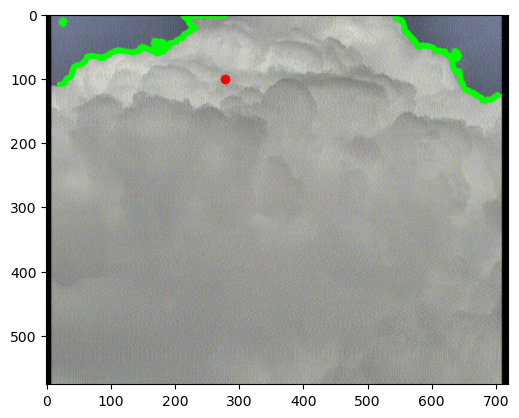

In [50]:
plt.imshow(cloud_edge)
plt.plot(x, 576-pixel_height, 'ro')

# find cloud height

[LTC3244/20](https://www.sourcesecurity.com/datasheets/bosch-ltc-3214-20/co-289-ga/FixedLenses.pdf)



In [60]:
pixel_height-576+576/2

188.0

In [61]:
calculator=hc.CloudHeightCalculator(158,D,aircraft_pass_position['pitch']-3)
height_corrected =calculator.calculate_height()
print(height_corrected)

523.3385435068008


In [66]:
x=D*math.tan(math.radians(aircraft_pass_position['pitch']-3))

In [67]:
x

128.78078191364938

In [68]:
cloud_top_height = height_corrected -x + aircraft_position['alt']

In [69]:
print('the estimated cloud top height is: ', cloud_top_height)

the estimated cloud top height is:  6409.633445186902


In [70]:
print('the pass height was: ', aircraft_pass_position['alt'])

the pass height was:  6112.783


In [71]:
aircraft_pass_position['alt']-cloud_top_height

-296.85024206190155